In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
base_caminho = "db\\Base de Vendas Periodo Dez, Jan, Fev.csv"

In [18]:
base_vendas = pd.read_csv(base_caminho, sep=";", encoding="utf-8")

In [19]:
vendas_linha_tempo = (
    base_vendas.groupby(["MES"])
    ["VALORLIQUIDO"]
    .sum()
    .reset_index()
)

display(vendas_linha_tempo)

,MES,VALORLIQUIDO
0,Dezembro,3.495532e+08
1,Fevereiro,1.274223e+08
2,Janeiro,4.098205e+08


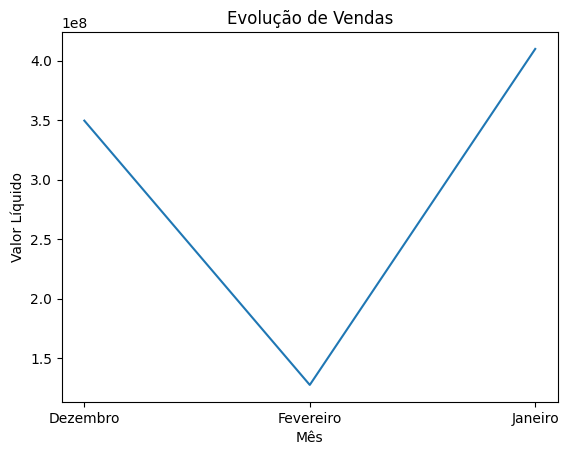

In [20]:
plt.plot(vendas_linha_tempo["MES"], vendas_linha_tempo["VALORLIQUIDO"])
plt.title("Evolução de Vendas")
plt.xlabel("Mês")
plt.ylabel("Valor Líquido")
plt.show()

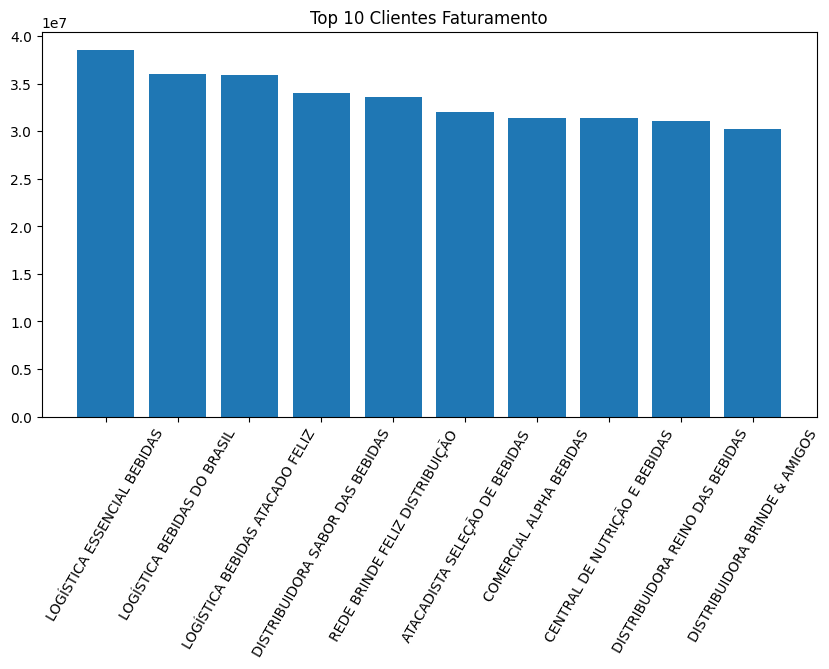

In [ ]:
produtos_maior_faturamento = (
    base_vendas.groupby(["DESCRICAOCLIENTE"])
    ["VALORLIQUIDO"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(produtos_maior_faturamento["DESCRICAOCLIENTE"], produtos_maior_faturamento["VALORLIQUIDO"])
plt.xticks(rotation=60)
plt.title("Top 10 Clientes Faturamento")
plt.show()

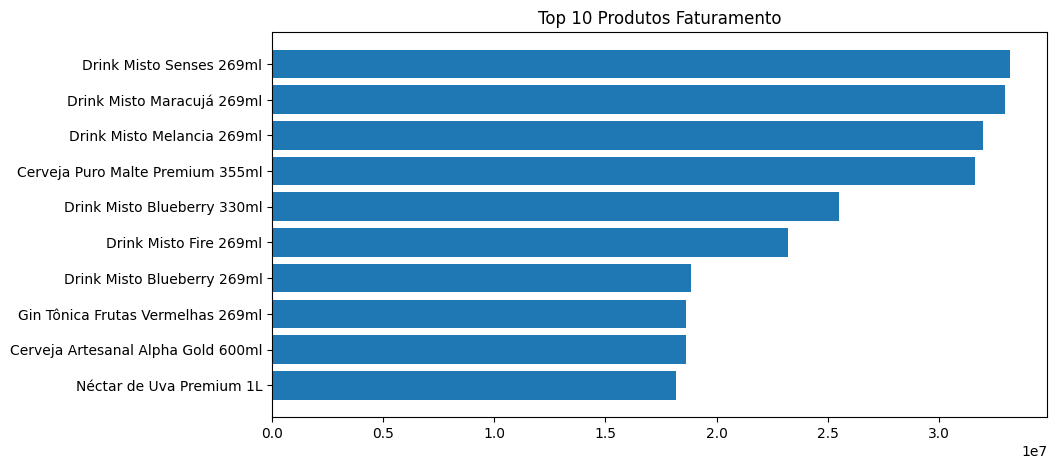

In [36]:
produtos_maior_faturamento = (
    base_vendas.groupby(["NOMEPRODUTO"])
    ["VALORLIQUIDO"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(produtos_maior_faturamento["NOMEPRODUTO"], produtos_maior_faturamento["VALORLIQUIDO"])
plt.gca().invert_yaxis()
plt.title("Top 10 Produtos Faturamento")
plt.show()

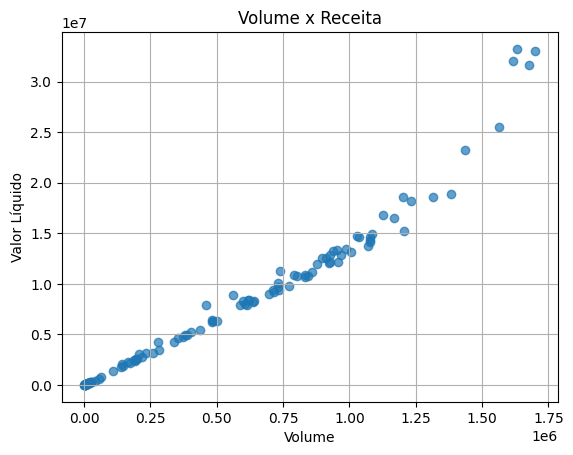

In [38]:
volume_receita_relacao = (
    base_vendas.groupby(["NOMEPRODUTO"])
    [["VOLUME", "VALORLIQUIDO"]]
    .sum()
    .reset_index()
)

plt.figure()
plt.scatter(volume_receita_relacao["VOLUME"], volume_receita_relacao["VALORLIQUIDO"], alpha=0.7) # Alpha = Opacidade
plt.title("Volume x Receita")
plt.xlabel("Volume")
plt.ylabel("Valor Líquido")
plt.grid()
plt.show()

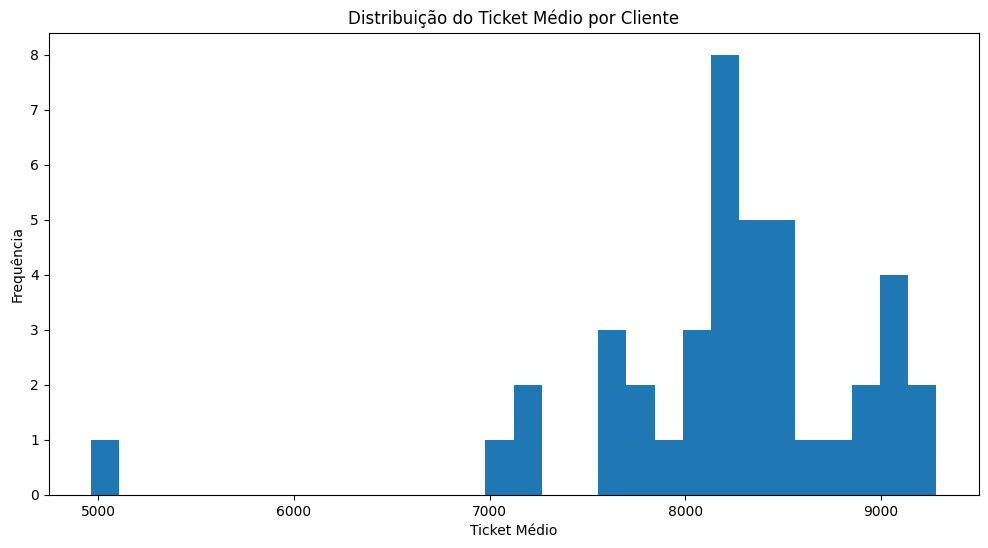

In [44]:
ticket_medio_cliente = (
    base_vendas.groupby(["DESCRICAOCLIENTE"])
    ["VALORLIQUIDO"]
    .mean()
)

plt.figure(figsize=(12, 6))
plt.hist(ticket_medio_cliente, bins=30)
plt.title("Distribuição do Ticket Médio por Cliente")
plt.xlabel("Ticket Médio")
plt.ylabel("Frequência")
plt.show()



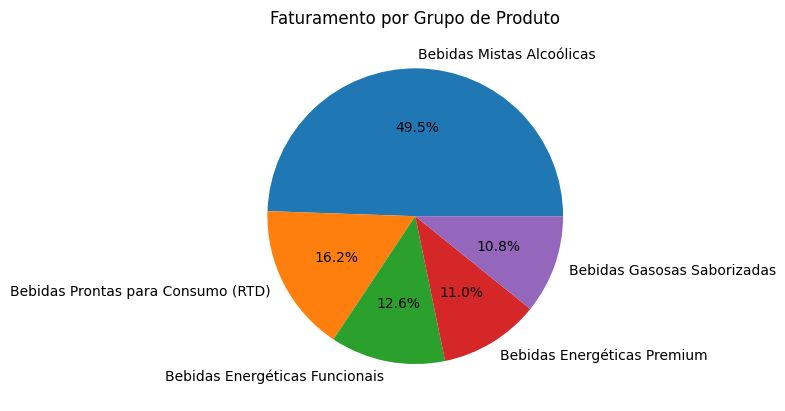

In [ ]:
tipo_produto_faturamento = (
    base_vendas.groupby(["DESCRICAOGRUPOPRODUTO"])
    ["VALORLIQUIDO"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure()
plt.pie(tipo_produto_faturamento, labels=tipo_produto_faturamento.index.to_list(), autopct="%1.1f%%") # autopct para aparecer porcentagens e o valor é formatação de casas decimais
plt.title("Faturamento por Grupo de Produto")
plt.show()
